In [1]:
import sys
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Ellipse, Polygon
import matplotlib.ticker as mticker
#M = scaler.fit_transform(M)
scaler = MinMaxScaler()
import pandas as pd
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
import sklearn
from scipy.signal import savgol_filter
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

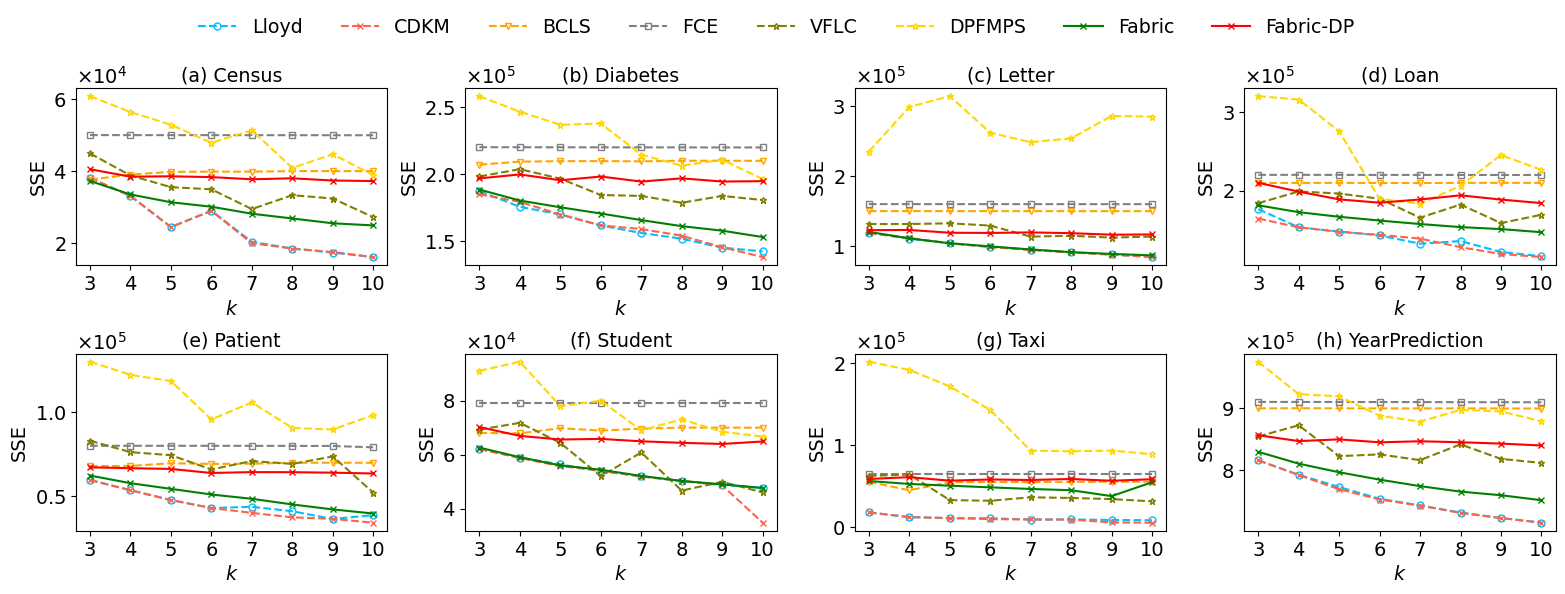

<Figure size 100x400 with 0 Axes>

In [17]:
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
#labels = ["Sorting","AutoIS","Avg-Finding","Quantile","MOM","MaxMin","$R^{*}$","Quadtree","Grid","ZM","Learned ZM"]
labels = ["Lloyd","CDKM","BCLS", "FCE","VFLC", "DPFMPS","Fabric","Fabric-DP","x", "x"]
df = pd.read_csv('./fig1.csv')
df = df.to_numpy()





#fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,1,figsize=(14, 2))
fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()
plt.figure(figsize=(1,4))
#axs[0,0].set_xlabel('X axis', fontsize = fs)
#axs[0,0].set_ylabel('y axis', fontsize = fs)
makesize = 5
linestyle1= '-.'
#3,2,6,10,1,9,4,8,11,5,7

# def drawMapWithLabels(start_row, row_num, ax):
#     for i in range(1, row_num + 1):
#         linestyle='-'
#         ax.plot(df[0], df[i + start_row],linestyle=linestyle, marker=marker[i-1],markersize=makesize, 
#                 markerfacecolor='none', markeredgewidth=markeredgewidth,color=colors[i-1],label=labels[i-1])

# def drawMap(start_row, row_num, ax):
#     for i in range(1, row_num + 1):
#         linestyle='-'
#         ax.plot(df[0],df[i + start_row],linestyle=linestyle, marker=marker[i-1],markersize=makesize,
#                 markerfacecolor='none', markeredgewidth=markeredgewidth,color=colors[i-1])

def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )


# row_num = 5
# drawMapWithLabels(0, 0, row_num, axs)
# drawMap(1, row_num * 1, row_num, axs)
# drawMap(2, row_num * 2, row_num, axs)
# drawMap(3, row_num * 3, row_num, axs)


row_num = 8
drawMapWithLabels(0, row_num, axs[0,0])
drawMap(row_num * 1, row_num, axs[0,1])
drawMap(row_num * 2, row_num, axs[0,2])
drawMap(row_num * 3, row_num, axs[0,3])
drawMap(row_num * 4, row_num, axs[1,0])
drawMap(row_num * 5, row_num, axs[1,1])
drawMap(row_num * 6, row_num, axs[1,2])
drawMap(row_num * 7, row_num, axs[1,3])

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.08),
          ncol=10, fancybox=False, shadow=False,frameon=False)


#设置表头大小 \n
# titles = ["(a) Athlete","(b) Spanish","(c) Pricerunner","(d) Diabetes"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

#设置横纵坐标的大小,x轴的坐标大小
# for i in range(0,4):
#     formatter = mticker.ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((-3, 3))  # 自动确定显示范围
#     axs[i].yaxis.set_major_formatter(formatter)
#     axs[i].set_title(titles[i], fontsize = fs*0.98, pad=5)
#     axs[i].set_ylabel('SSE', fontsize = fs)
#     # axs[i].set_yscale("log")wq
#     axs[i].set_xlabel("$k$", fontsize = fs*0.98)
#     axs[i].set_xticks([1,2,3,4,5,6,7,8])
#     axs[i].set_xticklabels(['3','4','5', '6','7','8','9','10'])

for i in range(8):
    row = i // 4
    col = i % 4
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[row,col].yaxis.set_major_formatter(formatter)
    axs[row,col].set_title(titles[i], fontsize = fs*0.98, pad=5)
    axs[row,col].set_ylabel('SSE', fontsize = fs)
    axs[row,col].set_xlabel("$k$", fontsize = fs*0.98)
    axs[row,col].set_xticks([1,2,3,4,5,6,7,8])
    axs[row,col].set_xticklabels(['3','4','5', '6','7','8','9','10'])
    

fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.subplots_adjust(hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./SSE.pdf", format="pdf", bbox_inches="tight")
plt.show()

['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']


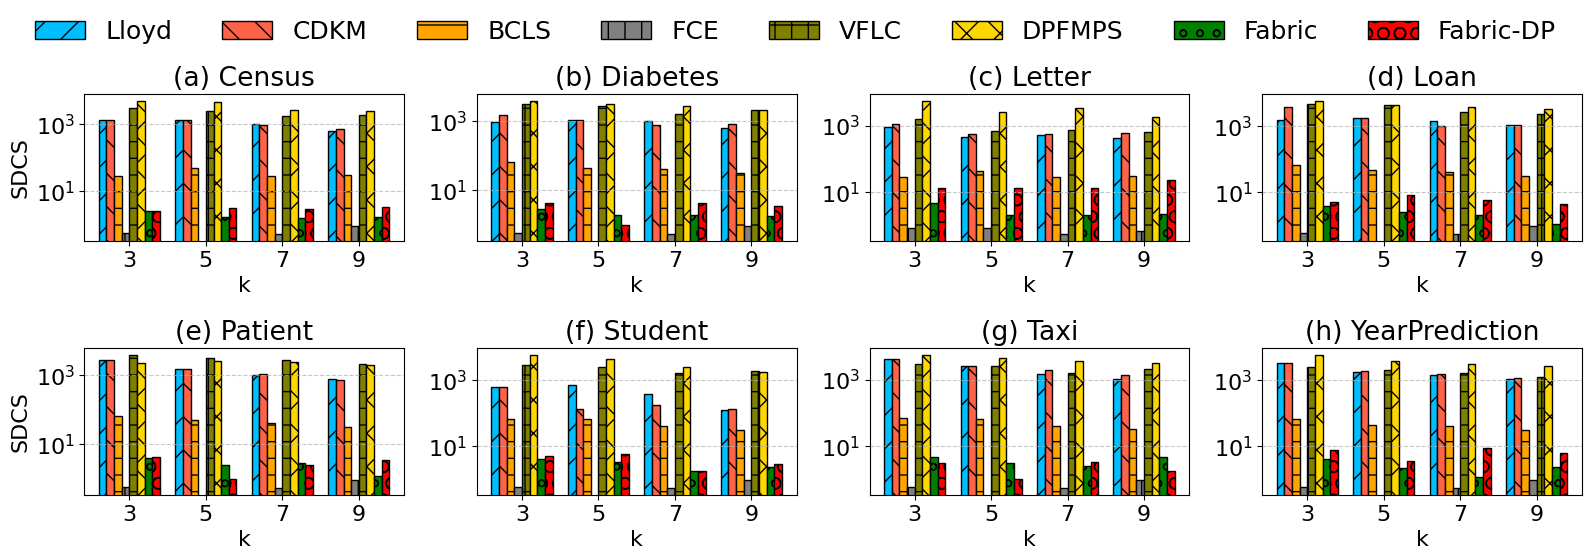

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl

# Matplotlib settings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 16})

# Define patterns and colors
patterns = ['/', '\\', '-', '|', '+', 'x', 'o', 'O', '.', '*']
# colors = ['#FFFFFF', '#CCCCCC', '#666666', '#999999', '#000000']
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
# Load data from Excel
df = pd.read_excel('Balance.xlsx')

# Ensure the 'k' column is integer for sorting
df['k'] = df['k'].astype(int)

# Define available options
available_datasets = df['Dataset'].unique().tolist()
available_methods = df['Method'].unique().tolist()
available_k = sorted(df['k'].unique())



# User selections

selected_datasets = ['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']  
selected_methods = ["Lloyd","CDKM","BCLS", "FCE","VFLC", "DPFMPS","Fabric","Fabric-DP"]


selected_k = [3,  5,  7,  9]  # Select k-values to display

# Filter the DataFrame based on selections
filtered_df = df[
    df['Dataset'].isin(selected_datasets) &
    df['Method'].isin(selected_methods) &
    df['k'].isin(selected_k)
]

# Pivot the data for easier plotting
pivot_df = filtered_df.pivot_table(
    index=['Dataset', 'k'],
    columns='Method',
    values='SDCS'
).reset_index()

# Sort the DataFrame
pivot_df.sort_values(['Dataset', 'k'], inplace=True)

# Number of datasets to plot
num_datasets = len(selected_datasets)

# Determine subplot grid size (e.g., 2x4 for 8 datasets)
n_cols = 4
n_rows = int(np.ceil(num_datasets / n_cols))

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(16.2, 5.6))
# fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))

axes = axes.flatten()  # Flatten in case of multiple rows

# 创建图例元素时添加 edgecolor='black'
legend_elements = [
    Patch(
        facecolor=colors[i],
        label=method,
        hatch=patterns[i % len(patterns)],
        edgecolor='black'  # 添加黑色边框
    ) 
    for i, method in enumerate(selected_methods)
]
print(selected_datasets)
# Plot each dataset
for idx, dataset in enumerate(selected_datasets):
    ax = axes[idx]
    data = pivot_df[pivot_df['Dataset'] == dataset]

  


    k_values = data['k'].tolist()
    x = np.arange(len(k_values))  # the label locations
    total_width = 0.8
    bar_width = total_width / len(selected_methods)

    for i, method in enumerate(selected_methods):
        balances = data[method].tolist()
        # Adjust the position for each method
        offset = (i - len(selected_methods)/2) * bar_width + bar_width/2
        ax.bar(
            x + offset, 
            balances, 
            bar_width, 
            label=method,
            color=colors[i % len(colors)],
            hatch=patterns[i % len(patterns)],
            edgecolor='black',  # 确保条形块有黑色边框
            # linewidth=1.5  # 可选：增加边框线宽
        )

    ax.set_title(f'({chr(97 + idx)}) {dataset}')  # 设置标题
    ax.set_xlabel('k')
    ax.set_xticks(x)
    ax.set_xticklabels(k_values)
    if idx % n_cols == 0:
        ax.set_ylabel('SDCS')
    ax.set_yscale('log') 
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove any unused subplots
# for j in range(idx + 1, n_rows * n_cols):
#     fig.delaxes(axes[j])

# 添加单个图例到顶部，具有黑色边框的图例块
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(selected_methods), 
    bbox_to_anchor=(0.5, 1.03), 
    fontsize=18, 
    frameon=False,  # 如果希望图例框本身有边框，可以设置为 True
)

# fig.tight_layout(rect=[0, 0, 1, 1.08])  # 调整布局以留出图例空间
# fig.tight_layout() 

fig.tight_layout(rect=[0, 0, 1, 0.95]) 
# fig.subplots_adjust(wspace=0.25, hspace=0.5, bottom=0.2) 
# fig.subplots_adjust(wspace=0.25)
# fig.subplots_adjust(hspace=0.5)
# Optional: Save the figure
plt.savefig('Balance.pdf')
mpl.rcParams.update({'font.size': 14})
# Show plot
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


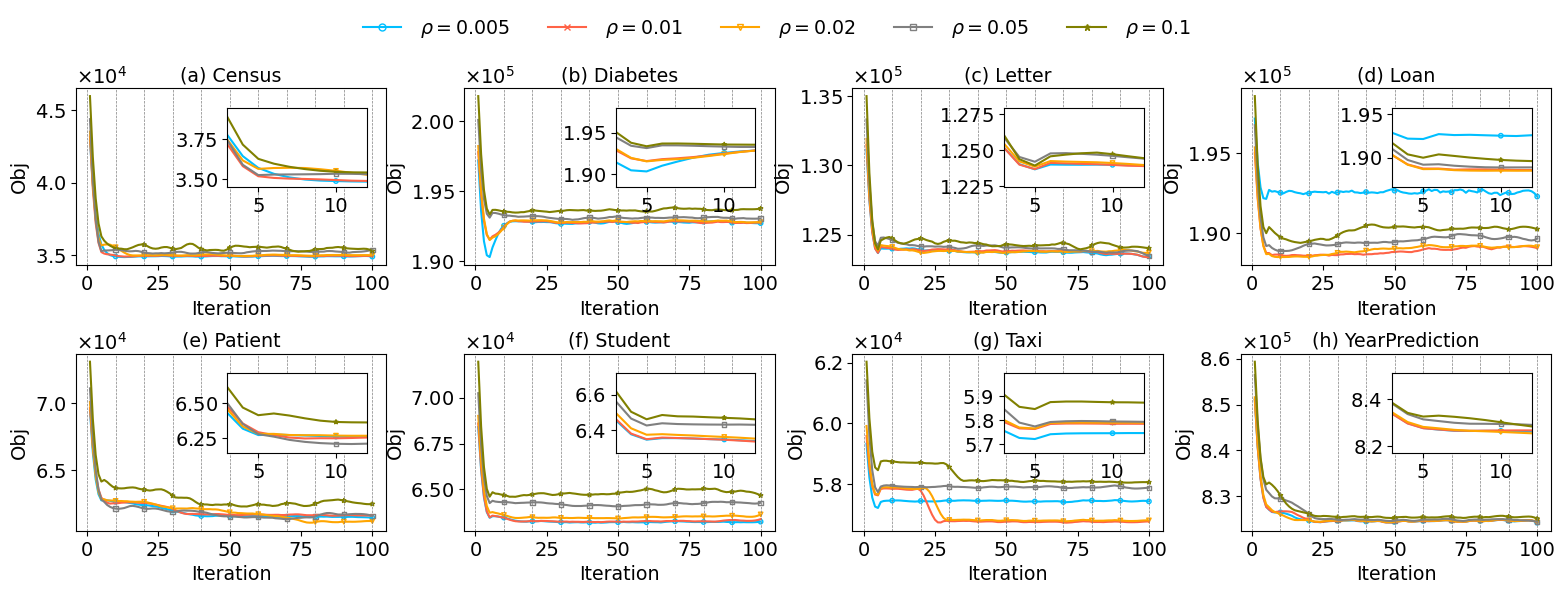

In [115]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置样式参数
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

# 读取数据
df = pd.read_csv('./fig3_1.csv', encoding='utf-8-sig').to_numpy()

# marker size：只在整10的iteration上加marker
makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    # 主图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 坐标轴设置
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    # 放大镜 inset_axes（嵌入右上角，宽高为原图的 45%）
    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    # 画放大图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 设置放大区间 x = [3, 12]，y 区间自动计算
    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

# 每张子图画主图和 inset
row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])

# 图例
handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset_with_inset_axes.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


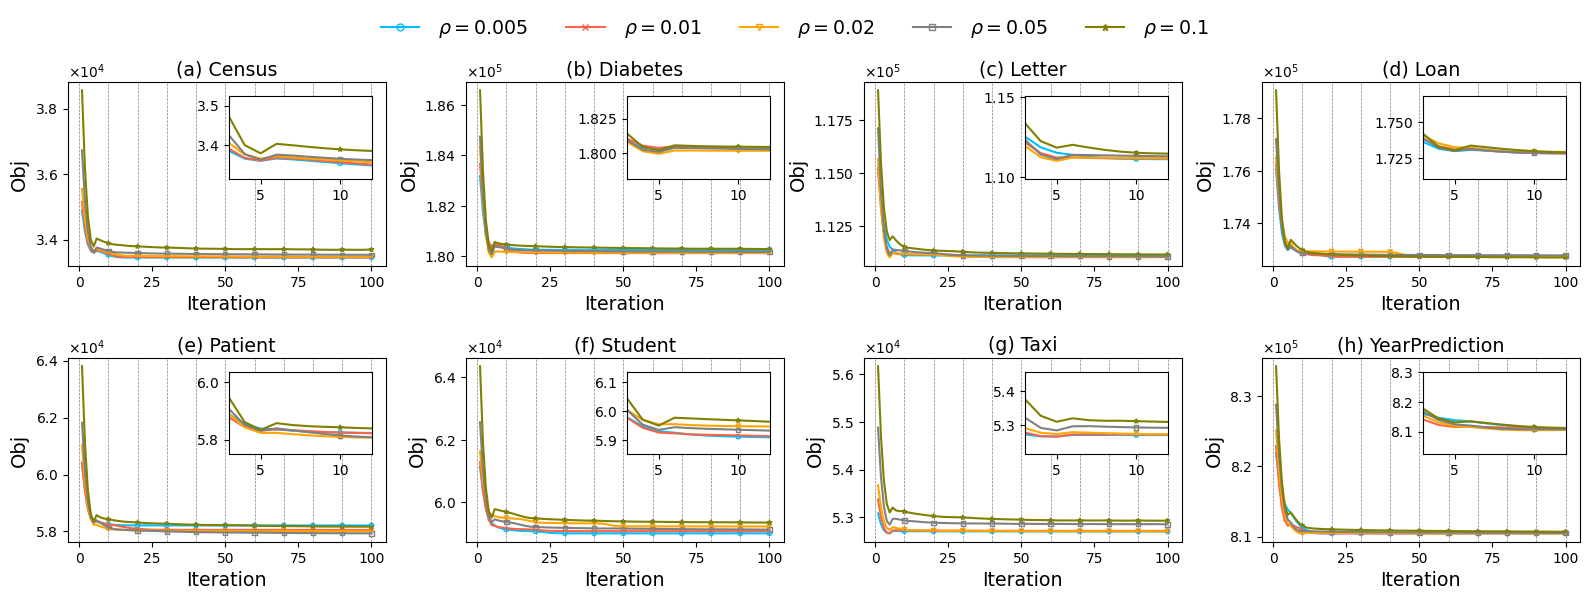

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置样式参数
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

# 读取数据
df = pd.read_csv('./fig3.csv', encoding='utf-8-sig').to_numpy()

# marker size：只在整10的iteration上加marker
makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    # 主图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 坐标轴设置
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    # 放大镜 inset_axes（嵌入右上角，宽高为原图的 45%）
    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    # 画放大图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 设置放大区间 x = [3, 12]，y 区间自动计算
    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

# 每张子图画主图和 inset
row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])

# 图例
handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


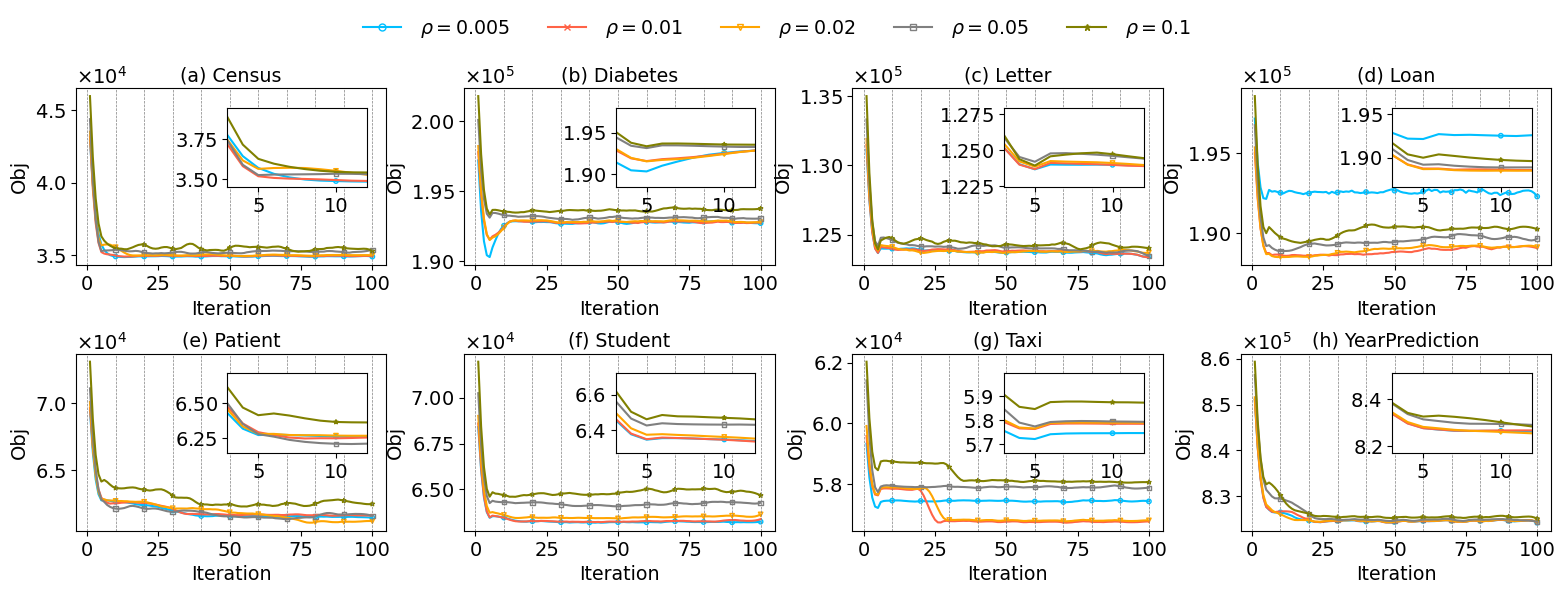

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置样式参数
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

# 读取数据
df = pd.read_csv('./fig3_1.csv', encoding='utf-8-sig').to_numpy()

# marker size：只在整10的iteration上加marker
makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    # 主图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 坐标轴设置
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    # 放大镜 inset_axes（嵌入右上角，宽高为原图的 45%）
    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    # 画放大图
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    # 设置放大区间 x = [3, 12]，y 区间自动计算
    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

# 每张子图画主图和 inset
row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])

# 图例
handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Datasetdp.pdf", format="pdf", bbox_inches="tight")
plt.show()


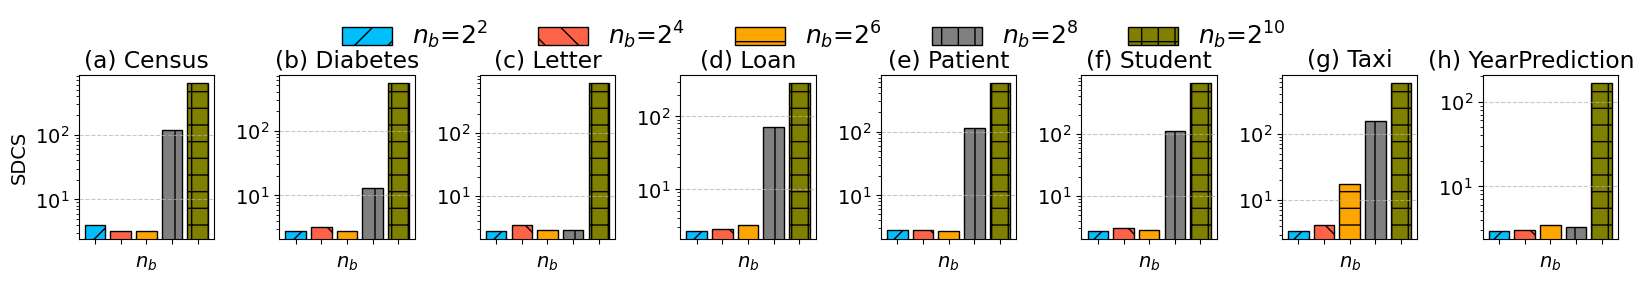

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
import math
# Matplotlib settings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 14})

# Define patterns and colors
patterns = ['/', '\\', '-', '|', '+', 'x', 'o', 'O', '.', '*']
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']

# Load data from CSV
df = pd.read_csv('./6blocksize.csv')
# df = pd.read_csv('./6blocksizedp.csv')
# Ensure the 'nb' column is integer for sorting
df['nb'] = df['nb'].astype(int)

# Define available options
available_datasets = df['Dataset'].unique().tolist()
available_methods = df['Method'].unique().tolist()
available_nb = sorted(df['nb'].unique())

# User selections
selected_datasets = ['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']  # Update datasets as needed
selected_methods = available_methods  # Use all methods (you can modify this if needed)

# Filter the DataFrame based on selections
filtered_df = df[
    df['Dataset'].isin(selected_datasets) &
    df['Method'].isin(selected_methods)
]

# Pivot the data for easier plotting
pivot_df = filtered_df.pivot_table(
    index=['Dataset', 'nb'],
    columns='Method',
    values='SDCS'
).reset_index()

# Sort the DataFrame
pivot_df.sort_values(['Dataset', 'nb'], inplace=True)

# Number of datasets to plot
num_datasets = len(selected_datasets)

# Determine subplot grid size (e.g., 2x4 for 8 datasets)
n_cols = 8
n_rows = int(np.ceil(num_datasets / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16.5, 2.8))
axes = axes.flatten()  # Flatten in case of multiple rows

# Determine unique nb values for the legend from the filtered data
unique_nbs = sorted(filtered_df['nb'].unique())

# Create legend elements for nb values with black border
legend_elements = [
    Patch(
        facecolor=colors[i % len(colors)],
        label=f'nb={unique_nbs[i]}',
        edgecolor='black'  # Add black border to the legend patches
    )
    for i in range(len(unique_nbs))
]

# Modify plotting logic for each bar to use unique patterns from the `patterns` list
for idx, dataset in enumerate(selected_datasets):
    ax = axes[idx]
    data = pivot_df[pivot_df['Dataset'] == dataset]

    nb_values = data['nb'].tolist()
    x = np.arange(len(nb_values))  # the label locations
    total_width = 0.8
    bar_width = total_width / len(selected_methods)

    # Map colors to nb values
    nb_color_mapping = {nb: colors[i % len(colors)] for i, nb in enumerate(unique_nbs)}

    # This will store custom legend handles for the nb values
    custom_legend_handles = []

    for i, method in enumerate(selected_methods):
        balances = data[method].tolist()
        # Adjust the position for each method
        offset = (i - len(selected_methods)/2) * bar_width + bar_width/2

        # Use the color corresponding to the nb value
        for j, nb in enumerate(nb_values):
            # Assign pattern from the `patterns` list for each bar
            pattern = patterns[(i * len(nb_values) + j) % len(patterns)]  # Unique pattern for each bar

            bar = ax.bar(
                x[j] + offset, 
                balances[j], 
                bar_width, 
                label=f'nb={nb}' if j == 0 else "",  # Add label for nb value only once for each method
                color=nb_color_mapping[nb],  # Set the color based on nb
                hatch=pattern,  # Set the hatch pattern for each bar
                edgecolor='black',  # Ensure bars have a black border
            )
            
            # Add label for the unique `nb` to the custom legend if it hasn't been added yet
            if j == 0:  # Only add the legend once per `nb`
                custom_legend_handles.append(Patch(facecolor=nb_color_mapping[nb], hatch=pattern, edgecolor='black', label=f'nb={nb}'))

    # ax.set_title(f'({chr(97 + idx)}) {dataset}')  # Set title
    # ax.set_title(f'({chr(97 + idx)}) {dataset}', loc='left', x=-0.05)

    if dataset ==  'YearPrediction':
        ax.set_title(f'({chr(97 + idx)}) {dataset}', loc='left', x=-0.4)
    else:
        ax.set_title(f'({chr(97 + idx)}) {dataset}')
    
    
    ax.set_xlabel('$n_b$')  # Set x-axis label as 'nb'
    ax.set_xticks(x)
    ax.set_xticklabels([])  # Remove x-axis tick labels
    if idx % n_cols == 0:
        ax.set_ylabel('SDCS')  # y-axis label
    ax.set_yscale('log')  # Use logarithmic scale for SDCS
    ax.grid(axis='y', linestyle='--', alpha=0.7)

unique_nbs = sorted(filtered_df['nb'].unique())

# Create legend elements for all nb values with colors and patterns
legend_elements = []
for i, nb in enumerate(unique_nbs):
    # 计算 n 的值，使得 2 ** n = nb
    n = int(math.log2(nb))
    pattern = patterns[i % len(patterns)]
    color = colors[i % len(colors)]
    legend_elements.append(Patch(
        facecolor=color,
        hatch=pattern,
        edgecolor='black',
        # 以 2 的 n 次幂形式显示
        label=f'$n_b$=$2^{{{n}}}$'
    ))

# Add a custom legend with both colors and patterns for each nb value
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(unique_nbs), 
    bbox_to_anchor=(0.5, 1.06), 
    fontsize=18, 
    frameon=False,  # Set to True if you want a border around the legend box
)

# Adjust layout to leave space for the legend
fig.tight_layout(rect=[0, 0, 1, 0.95])

# Optional: Save the figure
plt.savefig('./Obj6blocksize.pdf')
# plt.savefig('./Obj6blocksizedp.pdf')

# Show plot
plt.show()



In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

# 读取CSV数据
df = pd.read_csv('./6blocksize.csv')

# 选择的数据集标签（注意大小写）
selected_datasets = ["Athlete", "Spanish", "Pricerunner", "Diabetes", "Census", "Student", "Cohort", "NHANES"]
# selected_datasets = ["Athlete","Spanish","Pricerunner","Diabetes"]
# selected_datasets = ["Census","Student","Cohort","NHANES"]

nb_values = [4, 16, 64, 256, 1024]  # nb配置值

# 提取每个数据集下每个nb的Obj值
obj_values = {dataset: [] for dataset in selected_datasets}

# 获取每个数据集的 Obj 值
for dataset in selected_datasets:
    dataset_data = df[df['Dataset'] == dataset]
    obj_values[dataset] = [dataset_data[dataset_data['nb'] == nb]['Obj'].values[0] for nb in nb_values]

# 设置柱状图的宽度
width = 0.15  # 每个柱子的宽度
x = np.arange(len(selected_datasets))  # 数据集的索引

# 设置图表大小和样式
fig, ax = plt.subplots(figsize=(16,2.8))

# 设置柱状图的颜色和标记
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
hatches = ['/', '\\', '-', '|', '+']  # Valid hatch patterns

# 绘制柱状图
bars = []
for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        bar = ax.bar(x[i] + width * j, obj_values[dataset][j], width,edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])
        bars.append(bar)

# 设置标题和标签
# ax.set_title("Comparison of Obj across Datasets and nb values", fontsize=16)
ax.set_xlabel("Datasets", fontsize=16)
ax.set_ylabel("Obj", fontsize=16)
ax.set_xticks(x + width * 2)  # 每组柱子的中心
ax.set_xticklabels(selected_datasets)

# 创建图例：为每个 nb 添加图例
# 使用 Patch 来代替 Line2D
handles = []

    
legend_elements = [
    Patch(
        facecolor=colors[i],
        label=f'$n_b$={nb_values[i]}',
        hatch=hatches[i % len(hatches)],
        edgecolor='black'  
    ) 
    for i, method in enumerate(nb_values)
]


# 添加图例
# ax.legend(handles=handles, loc="upper left", fontsize=18, frameon=False)
    
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(nb_values), 
    bbox_to_anchor=(0.5, 1.15), 
    fontsize=18, 
    frameon=False,  # 如果希望图例框本身有边框，可以设置为 True
)
    
# 设置Y轴范围，以便适应所有数据
# ax.set_ylim(0, max([max(obj_values[dataset]) for dataset in selected_datasets]) * 1.1)
ax.set_yscale('log')  
# 添加网格线以增加可读性
# ax.grid(True, linestyle='--', alpha=0.7)

# 调整布局以防止标签重叠
fig.tight_layout()

# 保存为PDF文件
fig.savefig("./Obj6blocksize.pdf", format="pdf", bbox_inches="tight")

# 显示图表
plt.show()


KeyError: 'Obj'

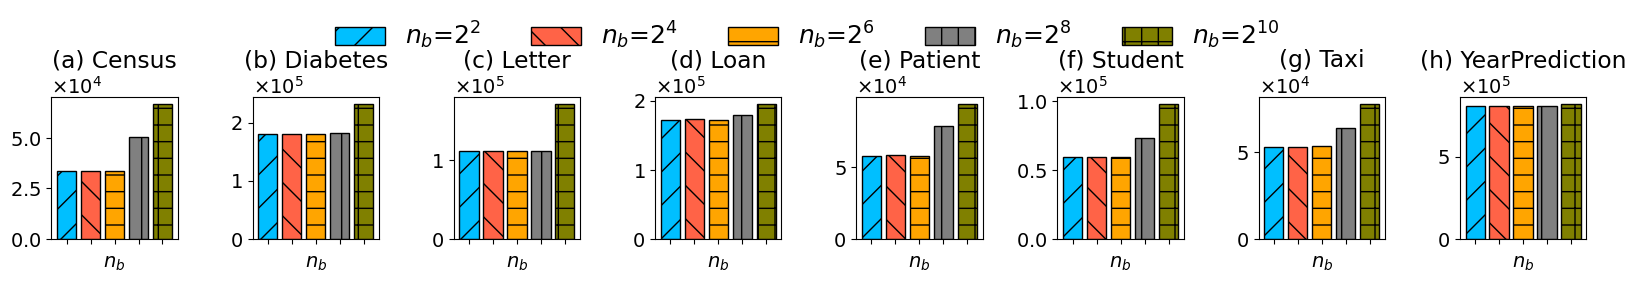

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib as mpl
import math
# Matplotlib settings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 14})

# Define patterns and colors
patterns = ['/', '\\', '-', '|', '+', 'x', 'o', 'O', '.', '*']
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']

# Load data from CSV
df = pd.read_csv('./6blocksize_1.csv')

# Ensure the 'nb' column is integer for sorting
df['nb'] = df['nb'].astype(int)

# Define available options
available_datasets = df['Dataset'].unique().tolist()
available_methods = df['Method'].unique().tolist()
available_nb = sorted(df['nb'].unique())

# User selections
selected_datasets = ['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']  # Update datasets as needed
selected_methods = available_methods  # Use all methods (you can modify this if needed)

# Filter the DataFrame based on selections
filtered_df = df[
    df['Dataset'].isin(selected_datasets) &
    df['Method'].isin(selected_methods)
]

# Pivot the data for easier plotting
pivot_df = filtered_df.pivot_table(
    index=['Dataset', 'nb'],
    columns='Method',
    values='Obj'
).reset_index()

# Sort the DataFrame
pivot_df.sort_values(['Dataset', 'nb'], inplace=True)

# Number of datasets to plot
num_datasets = len(selected_datasets)

# Determine subplot grid size (e.g., 2x4 for 8 datasets)
n_cols = 8
n_rows = int(np.ceil(num_datasets / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.8))
axes = axes.flatten()  # Flatten in case of multiple rows

# Determine unique nb values for the legend from the filtered data
unique_nbs = sorted(filtered_df['nb'].unique())

# Create legend elements for nb values with black border
legend_elements = [
    Patch(
        facecolor=colors[i % len(colors)],
        label=f'nb={unique_nbs[i]}',
        edgecolor='black'  # Add black border to the legend patches
    )
    for i in range(len(unique_nbs))
]

# Modify plotting logic for each bar to use unique patterns from the `patterns` list
for idx, dataset in enumerate(selected_datasets):
    ax = axes[idx]
    data = pivot_df[pivot_df['Dataset'] == dataset]

    nb_values = data['nb'].tolist()
    x = np.arange(len(nb_values))  # the label locations
    total_width = 0.8
    bar_width = total_width / len(selected_methods)

    # Map colors to nb values
    nb_color_mapping = {nb: colors[i % len(colors)] for i, nb in enumerate(unique_nbs)}

    # This will store custom legend handles for the nb values
    custom_legend_handles = []

    for i, method in enumerate(selected_methods):
        balances = data[method].tolist()
        # Adjust the position for each method
        offset = (i - len(selected_methods)/2) * bar_width + bar_width/2

        # Use the color corresponding to the nb value
        for j, nb in enumerate(nb_values):
            # Assign pattern from the `patterns` list for each bar
            pattern = patterns[(i * len(nb_values) + j) % len(patterns)]  # Unique pattern for each bar

            bar = ax.bar(
                x[j] + offset, 
                balances[j], 
                bar_width, 
                label=f'nb={nb}' if j == 0 else "",  # Add label for nb value only once for each method
                color=nb_color_mapping[nb],  # Set the color based on nb
                hatch=pattern,  # Set the hatch pattern for each bar
                edgecolor='black',  # Ensure bars have a black border
            )
            
            # Add label for the unique `nb` to the custom legend if it hasn't been added yet
            if j == 0:  # Only add the legend once per `nb`
                custom_legend_handles.append(Patch(facecolor=nb_color_mapping[nb], hatch=pattern, edgecolor='black', label=f'nb={nb}'))

    ax.set_title(f'({chr(97 + idx)}) {dataset}')  # Set title
    ax.set_xlabel('$n_b$')  # Set x-axis label as 'nb'
    ax.set_xticks(x)
    ax.set_xticklabels([])  # Remove x-axis tick labels
    
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)




unique_nbs = sorted(filtered_df['nb'].unique())

# Create legend elements for all nb values with colors and patterns
legend_elements = []
for i, nb in enumerate(unique_nbs):
    n = int(math.log2(nb))
    pattern = patterns[i % len(patterns)]
    color = colors[i % len(colors)]
    legend_elements.append(Patch(
        facecolor=color,
        hatch=pattern,
        edgecolor='black',
        # 以 2 的 n 次幂形式显示
        label=f'$n_b$=$2^{{{n}}}$'
    ))

# Add a custom legend with both colors and patterns for each nb value
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(unique_nbs), 
    bbox_to_anchor=(0.5, 1.06), 
    fontsize=18, 
    frameon=False,  # Set to True if you want a border around the legend box
)

# Adjust layout to leave space for the legend
fig.tight_layout(rect=[0, 0, 1, 0.95])




# 保存为PDF文件
fig.savefig("./SDCS6blocksize.pdf", format="pdf", bbox_inches="tight")

# 显示图表
plt.show()


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# 读取CSV数据
df_obj = pd.read_csv('./6blocksize.csv')
df_sdc = pd.read_csv('./6blocksize_1.csv')

# 选择的数据集标签（注意大小写）
selected_datasets = ["Athlete", "Spanish", "Pricerunner", "Diabetes"]
nb_values = [4, 16, 64, 256, 1024]  # nb配置值

# 提取每个数据集下每个nb的 Obj 和 SDCS 值
obj_values = {dataset: [] for dataset in selected_datasets}
sdc_values = {dataset: [] for dataset in selected_datasets}

for dataset in selected_datasets:
    # 获取 Obj 值
    dataset_data_obj = df_obj[df_obj['Dataset'] == dataset]
    obj_values[dataset] = [dataset_data_obj[dataset_data_obj['nb'] == nb]['Obj'].values[0] for nb in nb_values]

    # 获取 SDCS 值
    dataset_data_sdc = df_sdc[df_sdc['Dataset'] == dataset]
    sdc_values[dataset] = [dataset_data_sdc[dataset_data_sdc['nb'] == nb]['SDCS'].values[0] for nb in nb_values]

# 设置柱状图的宽度
width = 0.15  # 每个柱子的宽度
x = np.arange(len(selected_datasets))  # 数据集的索引

# 设置图表大小和样式
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 2.8))  # 创建两个并排的子图，调整图表大小

# 设置柱状图的颜色和标记
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
hatches = ['/', '\\', '-', '|', '+']  # Valid hatch patterns

# 绘制第一个子图：SDCS 值
for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        ax1.bar(x[i] + width * j, sdc_values[dataset][j], width, edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])

# 设置第一个子图标题和标签
ax1.set_xlabel("Datasets", fontsize=16)
ax1.set_ylabel("SDCS", fontsize=16)
ax1.set_xticks(x + width * 2)  # 每组柱子的中心
ax1.set_xticklabels(selected_datasets)
ax1.set_yscale('log')
# ax1.set_title("SDCS of Datasets at varying $n_b$", fontsize=16)

# 绘制第二个子图：Obj 值
for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        ax2.bar(x[i] + width * j, obj_values[dataset][j], width, edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])

# 设置第二个子图标题和标签
ax2.set_xlabel("Datasets", fontsize=16)
ax2.set_ylabel("Obj", fontsize=16)
ax2.set_xticks(x + width * 2)  # 每组柱子的中心
ax2.set_xticklabels(selected_datasets)
ax2.set_yscale('log')
# ax2.set_title("OBJ of Datasets at varying $n_b$", fontsize=16)

# 创建图例
legend_elements = [
    Patch(facecolor=colors[i], label=f'$n_b$={nb_values[i]}', hatch=hatches[i % len(hatches)], edgecolor='black') 
    for i, nb in enumerate(nb_values)
]

fig.legend(handles=legend_elements, loc='upper center', ncol=len(nb_values), bbox_to_anchor=(0.5, 1.07), fontsize=16, frameon=False)

# 调整布局以防止标签重叠
fig.tight_layout()

# 保存为PDF文件
fig.savefig("./SDCS_and_Obj_6blocksize.pdf", format="pdf", bbox_inches="tight")

# 显示图表
plt.show()


KeyError: 'Obj'

C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3251954890.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


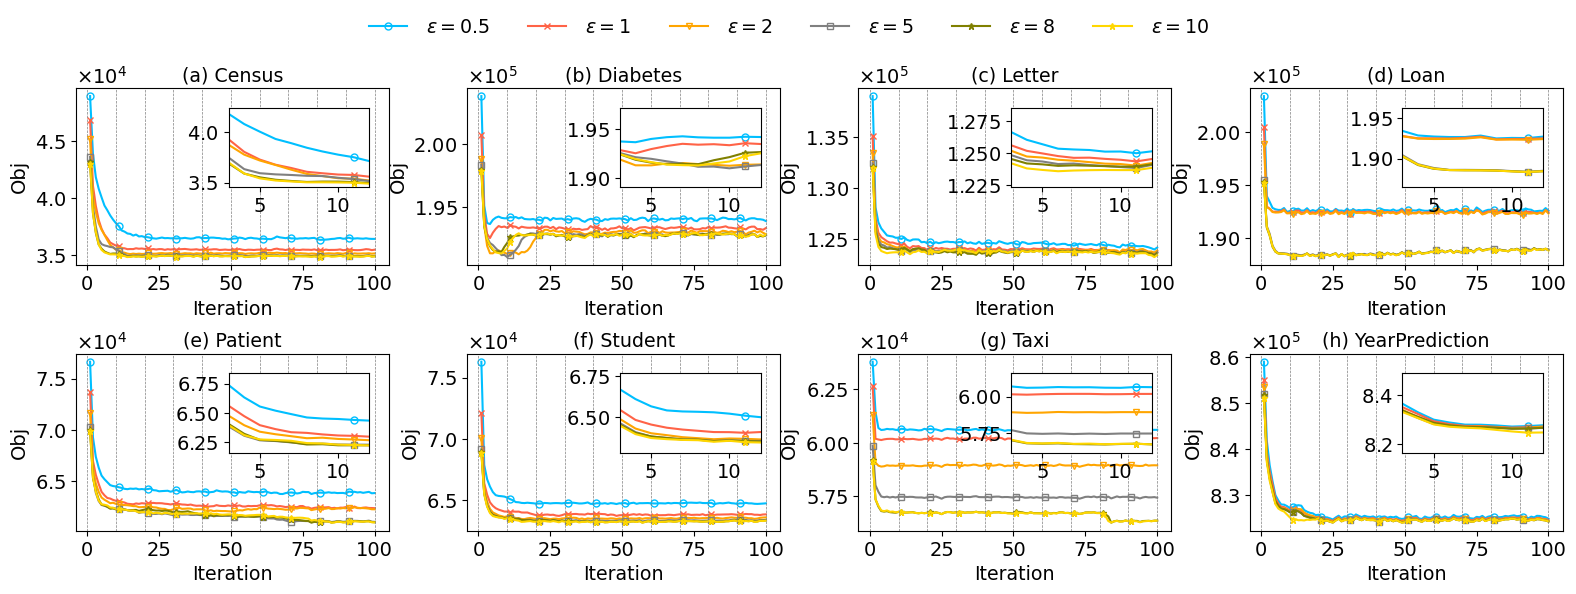

In [41]:
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.lines as mlines
# import matplotlib.ticker as mticker
# import matplotlib as mpl
# import pandas as pd

# # Set color and marker styles
# colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
# marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
# markeredgewidth = 1
# labels = ["$\\epsilon=0.5$","$\\epsilon=1$","$\\epsilon=2$","$\\epsilon=5$","$\\epsilon=8$","$\\epsilon=10$"]

# # Load data
# df = pd.read_csv('./fig4.csv')
# df = df.to_numpy()

# # Initialize plot
# fs = 14
# fig, axs = plt.subplots(2, 4, figsize=(16, 5.6))  # Two rows, four columns
# fig.tight_layout(pad=2.0)

# # Define size for markers
# makesize = np.zeros(len(df[0]))
# makesize[np.mod(df[0], 10) == 0] = 10
# linestyle1 = '-.'

# # Smoothing function (stub for now)
# def smooth_data(data):
#     window_length = 6  # Must be an odd number
#     polyorder = 3  # Polynomial order
#     return data

# # Function to draw plots with labels
# def drawMapWithLabels(x, start_row, row_num, axs):
#     for i in range(1, row_num + 1):
#         linestyle = '-'
#         axs[x//4, x%4].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
#         axs[x//4, x%4].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

# # Function to draw plots without labels
# def drawMap(x, start_row, row_num, axs):
#     for i in range(1, row_num + 1):
#         linestyle = '-'
#         axs[x//4, x%4].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
#         axs[x//4, x%4].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

# row_num = 6
# # Draw maps with labels and without labels
# drawMapWithLabels(0, 0, row_num, axs)
# drawMap(1, row_num * 1, row_num, axs)
# drawMap(2, row_num * 2, row_num, axs)
# drawMap(3, row_num * 3, row_num, axs)

# drawMapWithLabels(4, row_num * 4, row_num, axs)
# drawMap(5, row_num * 5, row_num, axs)
# drawMap(6, row_num * 6, row_num, axs)
# drawMap(7, row_num * 7, row_num, axs)

# # Add legend
# handles = []
# for idx, (color, marker) in enumerate(zip(colors, marker)):
#     handle = mlines.Line2D([], [], linestyle='-', color=color, marker=marker,
#                            markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
#     handles.append(handle)

# fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=10, bbox_to_anchor=(0.5, 1.08),
#               fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

# # Set titles for each subplot
# titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]
# for i in range(0, 8):
#     formatter = mticker.ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((-3, 3))  # Automatically adjust display range
#     axs[i//4, i%4].yaxis.set_major_formatter(formatter)  # Access each subplot
#     axs[i//4, i%4].set_title(titles[i], fontsize = fs*0.98, pad=5)
#     axs[i//4, i%4].set_ylabel('Obj', fontsize = fs)
#     axs[i//4, i%4].set_xlabel("Iteration", fontsize = fs*0.98)

#     # Add vertical lines
#     for j in range(0, 11, 1):
#         axs[i//4, i%4].axvline(x=j*10, color='gray', linestyle='--', linewidth=0.5)

# # Adjust layout and save
# fig.tight_layout()
# fig.subplots_adjust(wspace=0.25)
# fig.subplots_adjust(hspace=0.5)
# mpl.rcParams.update({'font.size': 14})
# fig.savefig("./Loss_per_Dataset_DP_epsilon.pdf", format="pdf", bbox_inches="tight")

# # Show plot
# plt.show()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib as mpl
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set color and marker styles
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\epsilon=0.5$","$\\epsilon=1$","$\\epsilon=2$","$\\epsilon=5$","$\\epsilon=8$","$\\epsilon=10$"]

# Load data
df = pd.read_csv('./fig4.csv')
df = df.to_numpy()

# Initialize plot
fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6))
fig.tight_layout(pad=2.0)

# Smoothing stub
def smooth_data(data):
    return data

# Helper to draw inset zoom
def add_inset(ax, start_row, row_num):
    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)
    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []

    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i - 1])
        # 添加 marker：每 10 个点显示一次
        axins.plot(df[0][::10], smoothed[::10], linestyle='None', color=colors[i - 1],
                   marker=marker[i - 1], markersize=5, markerfacecolor='none',
                   markeredgecolor=colors[i - 1], markeredgewidth=markeredgewidth)
        y_vals.extend(smoothed[idx_range])

    y1, y2 = min(y_vals) * 0.99, max(y_vals) * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

# Draw plots with labels
def drawMapWithLabels(x, start_row, row_num, axs):
    ax = axs[x // 4, x % 4]
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i - 1])
        ax.plot(df[0][::10], smoothed[::10], linestyle='None', color=colors[i - 1],
                marker=marker[i - 1], markersize=5, markerfacecolor='none',
                markeredgecolor=colors[i - 1], markeredgewidth=markeredgewidth)
    add_inset(ax, start_row, row_num)

# Draw plots without labels
def drawMap(x, start_row, row_num, axs):
    ax = axs[x // 4, x % 4]
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i - 1])
        ax.plot(df[0][::10], smoothed[::10], linestyle='None', color=colors[i - 1],
                marker=marker[i - 1], markersize=5, markerfacecolor='none',
                markeredgecolor=colors[i - 1], markeredgewidth=markeredgewidth)
    add_inset(ax, start_row, row_num)

row_num = 6
# Draw maps
drawMapWithLabels(0, 0, row_num, axs)
drawMap(1, row_num * 1, row_num, axs)
drawMap(2, row_num * 2, row_num, axs)
drawMap(3, row_num * 3, row_num, axs)
drawMapWithLabels(4, row_num * 4, row_num, axs)
drawMap(5, row_num * 5, row_num, axs)
drawMap(6, row_num * 6, row_num, axs)
drawMap(7, row_num * 7, row_num, axs)

# Add legend
handles = []
for idx, (color, marker) in enumerate(zip(colors, marker)):
    handle = mlines.Line2D([], [], linestyle='-', color=color, marker=marker,
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=10, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

# Set titles and axes
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]
for i in range(0, 8):
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[i // 4, i % 4].yaxis.set_major_formatter(formatter)
    axs[i // 4, i % 4].set_title(titles[i], fontsize=fs*0.98, pad=5)
    axs[i // 4, i % 4].set_ylabel('Obj', fontsize=fs)
    axs[i // 4, i % 4].set_xlabel("Iteration", fontsize=fs*0.98)
    for j in range(0, 11):
        axs[i // 4, i % 4].axvline(x=j * 10, color='gray', linestyle='--', linewidth=0.5)

# Final layout and export
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset_DP_epsilon.pdf", format="pdf", bbox_inches="tight")
plt.show()



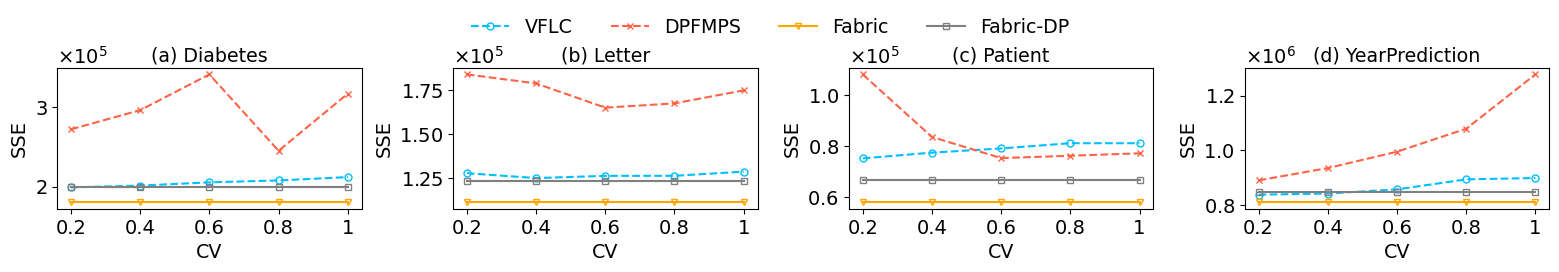

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["VFLC", "DPFMPS", "Fabric", "Fabric-DP", "x", "x"]

df = pd.read_csv('./fig_random.csv')
df = df.to_numpy()

fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))  
makesize = 5

def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用实线，其他虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )
    # ax.legend(fontsize=fs*0.9)

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )

row_num = 4
drawMapWithLabels(0, row_num, axs[0])
drawMap(row_num * 1, row_num, axs[1])
drawMap(row_num * 2, row_num, axs[2])
drawMap(row_num * 3, row_num, axs[3])

titles = ["(a) Diabetes", "(b) Letter", "(c) Patient", "(d) YearPrediction"]

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.01),
          ncol=10, fancybox=False, shadow=False,frameon=False)


for i in range(4):
    axs[i].set_title(titles[i], fontsize=fs*0.98, pad=5)
    axs[i].set_ylabel('SSE', fontsize=fs)
    axs[i].set_xlabel("CV", fontsize=fs*0.98)
    axs[i].set_xticks([1,2,3,4,5])
    axs[i].set_xticklabels(['0.2','0.4','0.6','0.8','1'])
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[i].yaxis.set_major_formatter(formatter)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./varFeature.pdf", format="pdf", bbox_inches="tight")
plt.show()


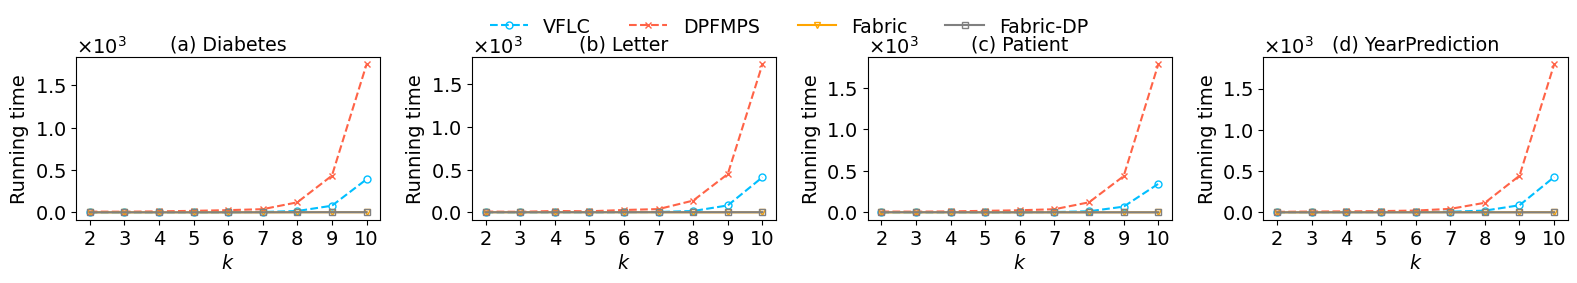

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["VFLC", "DPFMPS", "Fabric", "Fabric-DP", "x", "x"]

df = pd.read_csv('./varClient.csv')
df = df.to_numpy()

fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))  
makesize = 5

def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用实线，其他虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )
    # ax.legend(fontsize=fs*0.9)

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )

row_num = 4
drawMapWithLabels(0, row_num, axs[0])
drawMap(row_num * 1, row_num, axs[1])
drawMap(row_num * 2, row_num, axs[2])
drawMap(row_num * 3, row_num, axs[3])

titles = ["(a) Diabetes", "(b) Letter", "(c) Patient", "(d) YearPrediction"]

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.05),
          ncol=10, fancybox=False, shadow=False,frameon=False)


for i in range(4):
    axs[i].set_title(titles[i], fontsize=fs*0.98, pad=5)
    axs[i].set_ylabel('Running time', fontsize=fs)
    axs[i].set_xlabel("$k$", fontsize=fs*0.98)
    axs[i].set_xticks([1,2,3,4,5,6,7,8,9])
    axs[i].set_xticklabels(['2','3','4','5', '6','7','8','9','10'])
    

    
    
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[i].yaxis.set_major_formatter(formatter)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./varClient.pdf", format="pdf", bbox_inches="tight")
plt.show()
